---

# LESSON 15: REMOVING BORDERS

---

>---
>You can **remove specific chart borders** with `ax.spines[].set_visible(False)`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks')

In [2]:
df = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin', 'period_end'])

df = (df
    .pivot_table(index='period_begin', 
                 columns='region_name', 
                 values='median_active_list_price', 
                 aggfunc='mean')
    .resample('QE').mean().round()
)

df = df.reindex(columns=['San Francisco', 'Los Angeles', 'San Diego'])
    
display(df.head(3), df.tail(3))
df.info()

region_name,San Francisco,Los Angeles,San Diego
period_begin,,,
2017-03-31,1263499.0,630557.0,637701.0
2017-06-30,1259083.0,650077.0,652195.0
2017-09-30,1276378.0,651898.0,646279.0


region_name,San Francisco,Los Angeles,San Diego
period_begin,,,
2021-12-31,1314891.0,882856.0,827622.0
2022-03-31,1293413.0,900615.0,885798.0
2022-06-30,1292479.0,906774.0,902425.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2017-03-31 to 2022-06-30
Freq: QE-DEC
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   San Francisco  22 non-null     float64
 1   Los Angeles    22 non-null     float64
 2   San Diego      22 non-null     float64
dtypes: float64(3)
memory usage: 704.0 bytes


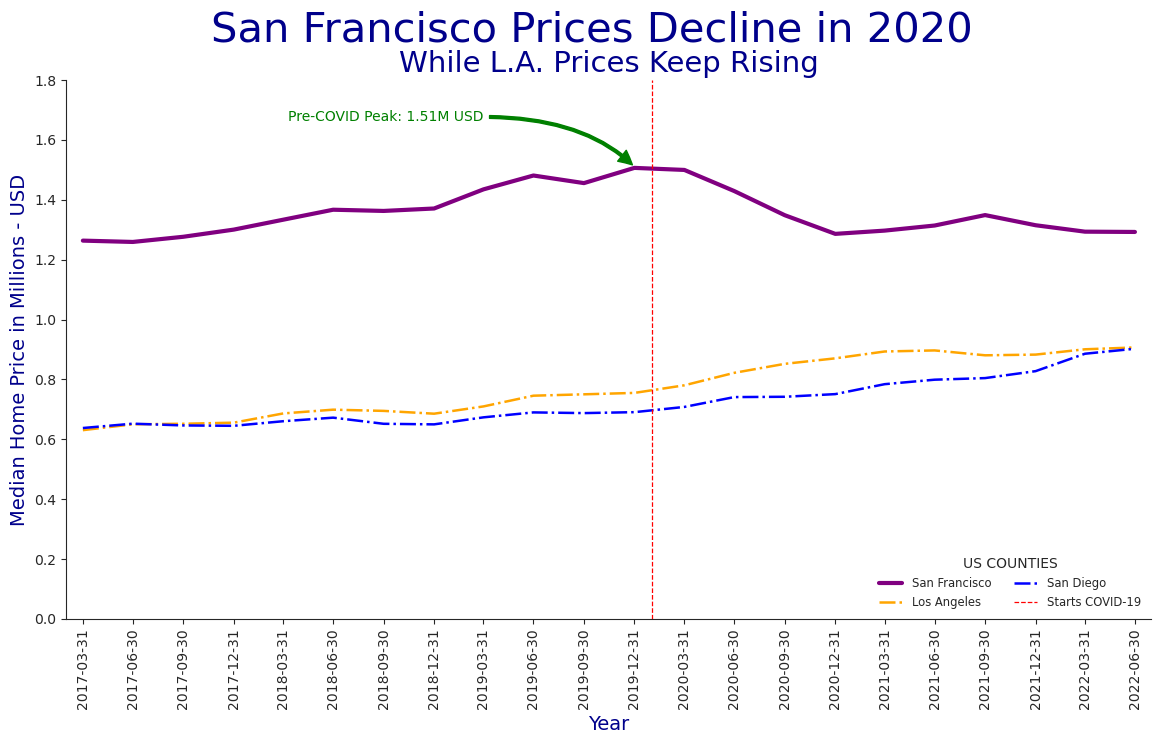

In [3]:
# Section 1: Initial Configuration
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df['San Francisco']/1e6, label='San Francisco',
        color='purple', linestyle='-', linewidth=3)

ax.plot(df['Los Angeles']/1e6, label='Los Angeles',
        color='orange', linestyle='-.', linewidth=1.8)

ax.plot(df['San Diego']/1e6, label='San Diego',
       color='blue', linestyle='-.', linewidth=1.8)

# Section 2: Titles
fig.suptitle('San Francisco Prices Decline in 2020', fontsize=30, color='darkblue')
ax.set_title('While L.A. Prices Keep Rising', fontsize=21, color='darkblue')
ax.set_xlabel('Year', fontsize=14, color='darkblue')
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=14, color='darkblue')

# Section 3: Axis limits
ax.set_xlim(pd.Timestamp('2017-03-01'), pd.Timestamp('2022-07-30'))
ax.set_ylim(0, 1.8)

# Section 4: Enhance X-Axis
ax.set_xticks(df.index)
plt.xticks(rotation=90)

# Section 5: Show Information
ax.axvline(pd.Timestamp('2020-02-01'), label='Starts COVID-19', color='red', linestyle='--', linewidth=0.9)
# ax.text(x=pd.Timestamp('2019-08-01'), y=1.2, s='COVID 19 --->', color='red')
# --------------------------------------
ax.annotate(
    text='Pre-COVID Peak: 1.51M USD',
    color='green',
    xy=(pd.Timestamp('2019-12-31'), 1.51),
    
    xytext=(pd.Timestamp('2019-03-31'), 1.7),
    verticalalignment='top',
    horizontalalignment='right',
    
    arrowprops=dict(
        arrowstyle='simple, head_width=1, head_length=1',
        color='green',
        relpos=(1, 0.5),
        connectionstyle='angle3, angleA=0, angleB=-45')
    )

# Section 6: Legend setting
ax.legend(loc='lower right', 
          ncols=2,
          title='US COUNTIES',
          title_fontsize='medium',
          fontsize='small',
          frameon=False,
         )

# Section 7: Removing borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Final Section: Clean Plot
plt.show()

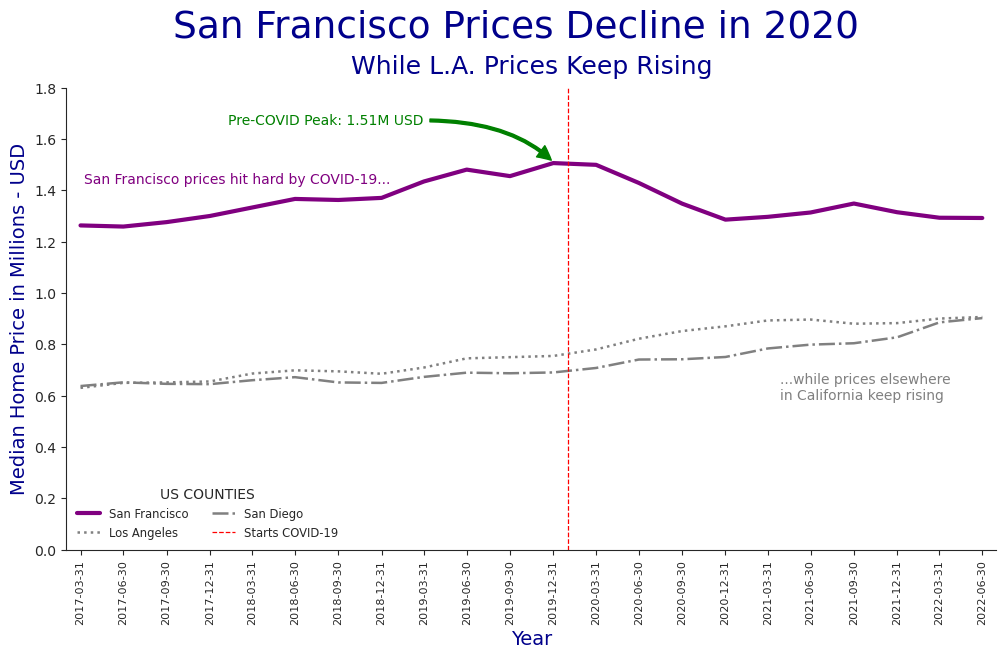

In [17]:
sns.set_style('ticks')

# Section 1: Initial Configuration & Plotting
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['purple', 'gray', 'grey']
lstyles = ['-', ':', '-.']
lwidth = [3, 1.8, 1.8]

for i, col, in enumerate(df):
    ax.plot(df[col]/1e6, label=col, 
            color=colors[i], 
            linestyle=lstyles[i], 
            linewidth=lwidth[i])

# Section 2: Titles 
fig.suptitle('San Francisco Prices Decline in 2020', fontsize=27, color='darkblue', y=1.01)
ax.set_title('While L.A. Prices Keep Rising', fontsize=18, color='darkblue', pad=10)
ax.set_xlabel('Year', fontsize=14, color='darkblue')
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=14, color='darkblue')

# Section 3: Axis limits
ax.set_xlim(pd.Timestamp('2017-03-01'), pd.Timestamp('2022-07-30'))
ax.set_ylim(0, 1.8)

# Section 4: Enhance X-Axis
ax.set_xticks(df.index)
plt.xticks(rotation=90, fontsize=8)

# Section 5: Show Information
ax.axvline(pd.Timestamp('2020-02-01'), label='Starts COVID-19', color='red', linestyle='--', linewidth=0.9)
# ax.text(x=pd.Timestamp('2019-08-01'), y=1.2, s='COVID 19 --->', color='red')
# --------------------------------------
ax.annotate(
    text='Pre-COVID Peak: 1.51M USD',
    color='green',
    xy=(pd.Timestamp('2019-12-31'), 1.51),
    
    xytext=(pd.Timestamp('2019-03-31'), 1.7),
    verticalalignment='top',
    horizontalalignment='right',
    
    arrowprops=dict(
        arrowstyle='simple, head_width=1, head_length=1',
        color='green',
        relpos=(1, 0.5),
        connectionstyle='angle3, angleA=0, angleB=-45')
    )

# Section 6: Legend setting
ax.legend(loc='lower left', 
          ncols=2,
          title='US COUNTIES',
          title_fontsize='medium',
          fontsize='small',
          frameon=False,
         )

# Section 7: Removing borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Section 8: Plot Personal Comments
fig.text(x=0.14, y=0.72,
         s='San Francisco prices hit hard by COVID-19...',
         color='purple', fontsize=10)

fig.text(x=0.72, y=0.36,
         s='...while prices elsewhere\nin California keep rising',
         color='gray', fontsize=10)

# Final Section: Clean Plot
plt.show()